# Categorical target encoding
**Assigned member:** Laknadi K. S. S. | **IT number:** IT25102419

**Group:** 26-MTR-SE2030-14 | **Dataset:** Letter Recognition

This notebook includes implementation, visible outputs, EDA, interpretation, and viva preparation. Run all cells and explain the decisions in your own words.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image

# Works when launched from the project root or the notebooks directory.
ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "pipeline.py").exists():
    ROOT = ROOT.parent
assert (ROOT / "src" / "pipeline.py").exists(), "Start Jupyter inside the extracted project folder."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.pipeline import (FEATURES, SEED, load_raw, audit_and_clean, split_data,
                          outlier_audit, fit_transforms, verify, run)
raw = load_raw(ROOT)
clean, audit, removed = audit_and_clean(raw)
splits = split_data(clean)
train = splits["train"]
print("Raw:", raw.shape, "Clean:", clean.shape)
print("Partitions:", {name: len(part) for name, part in splits.items()})


Raw: (20000, 17) Clean: (18668, 17)
Partitions: {'train': 13067, 'validation': 2800, 'test': 2801}


## Shared inputs
The integrated pipeline generates the common plot artifacts. If they are absent, the following cell regenerates them. This notebook's technique implementation below remains independently executable.

In [2]:
if not (ROOT / "results/eda_visualizations/10_outlier_rates.png").exists():
    run(ROOT)

## Technique and justification
LabelEncoder maps each letter to a stable class ID. It is fitted on the training labels and reused on the other partitions. All classes are present in training because the split is stratified. There are no categorical predictor columns requiring one-hot encoding.

In [3]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder().fit(train.letter)
y_train = encoder.transform(train.letter)
y_validation = encoder.transform(splits["validation"].letter)
y_test = encoder.transform(splits["test"].letter)
display(pd.DataFrame({"letter": encoder.classes_, "encoded": encoder.transform(encoder.classes_)}))
assert np.array_equal(encoder.inverse_transform(y_train), train.letter)
print("First 10 encoded labels:", y_train[:10])

,letter,encoded
0,A,0
1,B,1
2,C,2
3,D,3
4,E,4
5,F,5
6,G,6
7,H,7
8,I,8
9,J,9


First 10 encoded labels: [25  9  3  7  3 12  8 24 20 24]


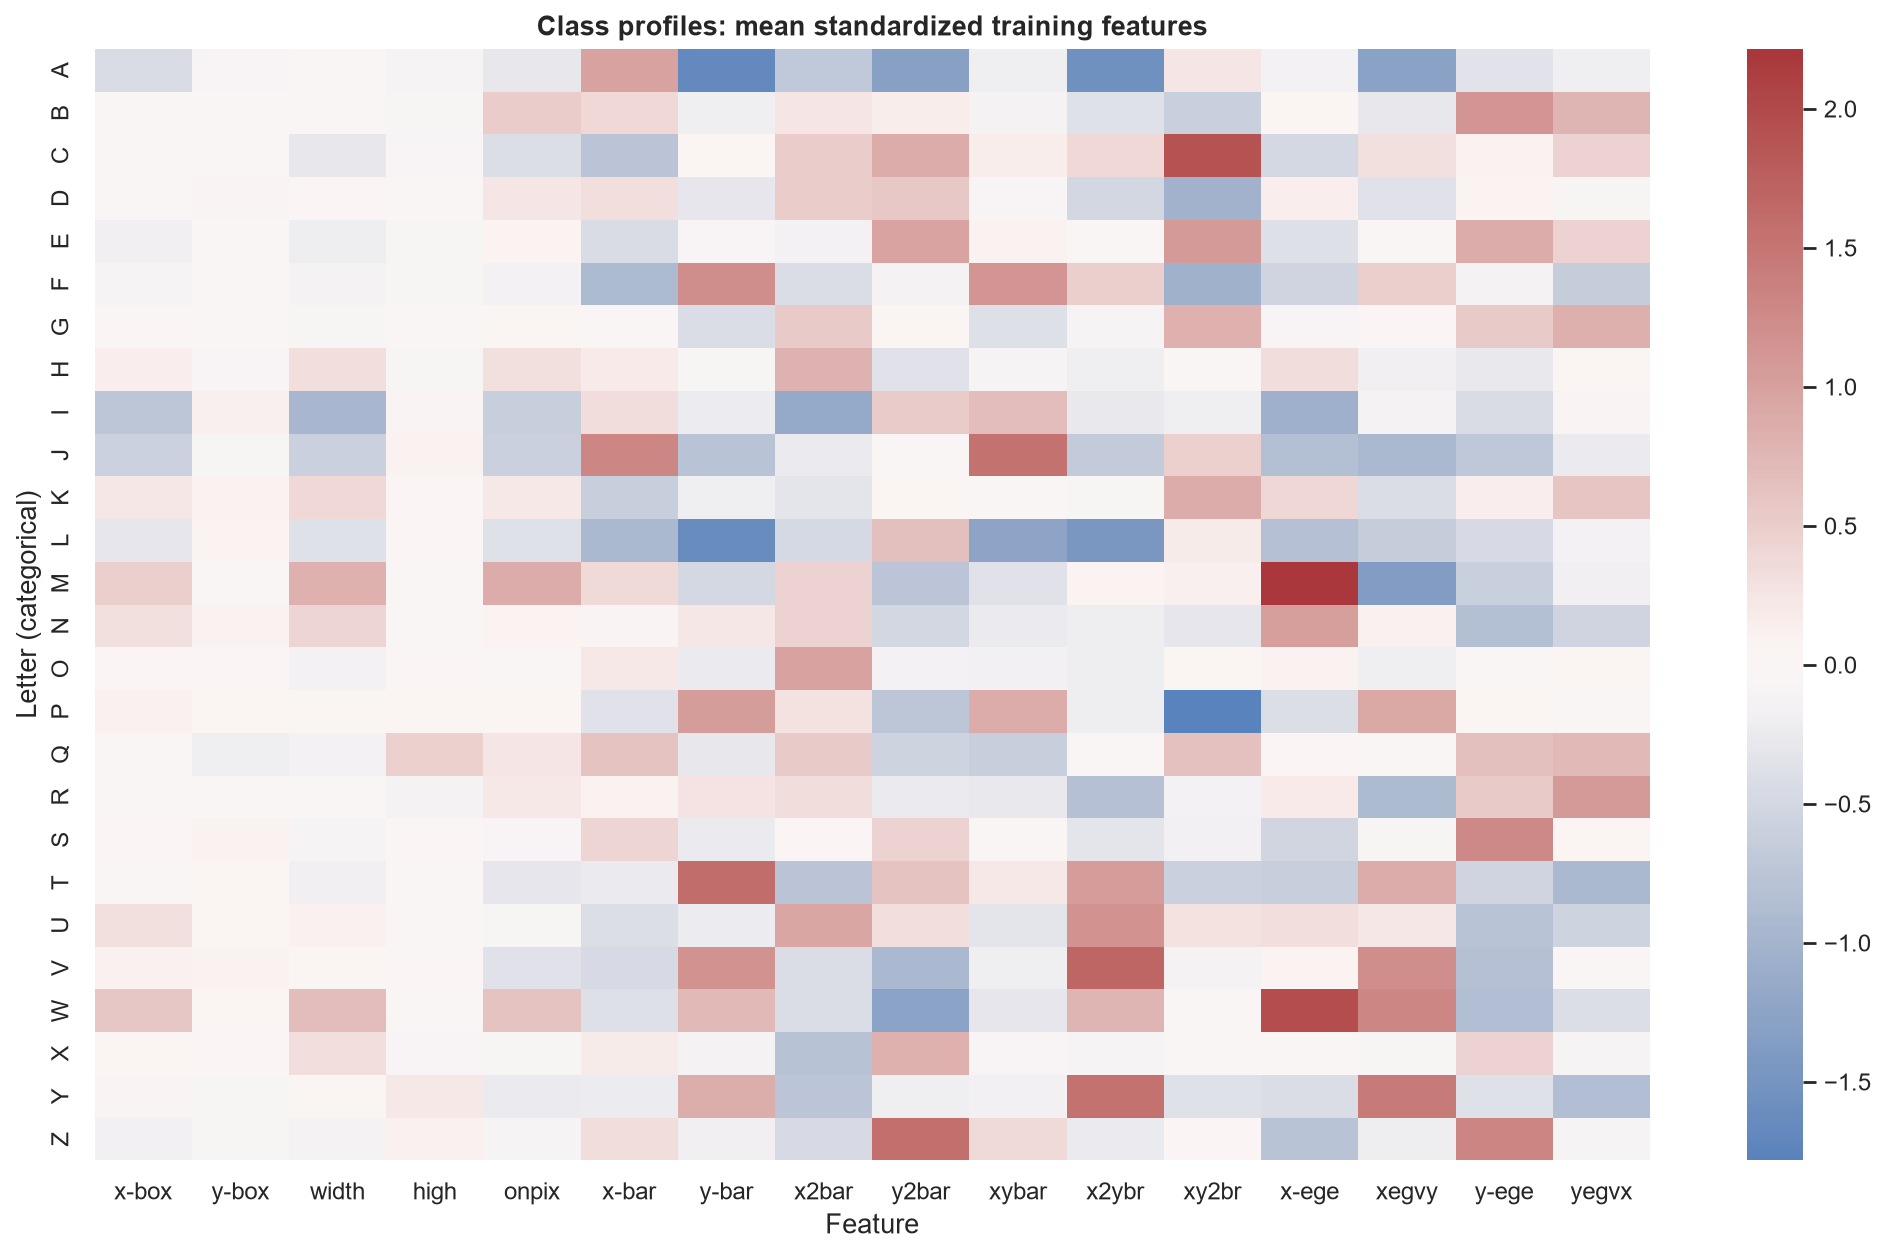

In [4]:
display(Image(filename=str(ROOT / "results/eda_visualizations/06_class_feature_profiles.png")))

## Interpretation
Each heatmap row is a letter; color shows its mean feature value after training standardization. Letters have different feature profiles, supporting analysis of feature combinations. The heatmap does not imply a numeric order between A and Z.

**Viva:** Does Z=25 mean it is 25 times A=0? No. These are class identifiers. Why not compute Pearson correlation with these IDs? It would impose an arbitrary numeric relationship on nominal categories.